# Customer Segmentation & Behavioral Analytics

**Authors:** Raj Kumar Mahato, Anshu Kumari

This notebook walks through the complete analysis step by step. The reusable code lives in the `src/` package; the notebook calls those functions and explains the reasoning and the results.

**Contents**
1. Problem statement
2. Dataset description
3. Import libraries
4. Load data
5. Data inspection
6. Data cleaning
7. Exploratory data analysis
8. Feature engineering
9. RFM calculation
10. RFM distributions and statistics
11. Feature scaling
12. K-Means clustering
13. Elbow method
14. Silhouette score
15. PCA visualisation
16. Cluster interpretation
17. Business insights
18. Conclusion

## 1. Problem statement

A business with thousands of customers cannot treat every customer the same way, but it also cannot design a separate strategy for each one. **Customer segmentation** groups customers with similar purchasing behaviour so that each group can be understood and served appropriately.

**Goal:** use transaction history to describe customers with three behavioural measures (Recency, Frequency, Monetary), group them with K-Means clustering, and interpret the groups in business terms.

**Questions**
- How is revenue distributed over time, products, countries and customers?
- Which natural customer groups exist in the RFM feature space, and how many are reasonable?
- What does each group look like, and how could a business act on it?

## 2. Dataset description

We use the public **UCI Online Retail** dataset (Chen, 2015; CC BY 4.0): 541,909 invoice lines from a UK-based online retailer between 01/12/2010 and 09/12/2011. Amounts are in pounds sterling (£).

| Column | Meaning |
|---|---|
| InvoiceNo | Invoice number; a leading `C` marks a cancellation |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units on the invoice line |
| InvoiceDate | Date and time of purchase |
| UnitPrice | Price per unit |
| CustomerID | Customer identifier |
| Country | Customer's country |

The code renames `InvoiceNo` to `Invoice`. See `data/README.md` for the source, license and download instructions.

## 3. Import libraries

In [1]:
import sys
from pathlib import Path

# Make the project root importable whether the notebook is started from
# the project root or from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import eda, clustering
from src import statistical_analysis as sa
from src.data_cleaning import load_raw_data, clean_transactions, validate_transactions
from src.download_data import download_dataset
from src.rfm_analysis import calculate_rfm, add_rfm_scores, RFM_FEATURES
from src.utils import SAMPLE_CSV, CURRENCY

%matplotlib inline
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

## 4. Load data

`download_dataset()` downloads the dataset from UCI the first time and reuses the local CSV afterwards. If the download is not possible, the notebook falls back to the small bundled sample (results will then differ from the ones discussed below, which come from the **full** dataset).

In [2]:
USE_SAMPLE = False  # set to True for a quick run on the bundled sample

if USE_SAMPLE:
    data_path = SAMPLE_CSV
else:
    try:
        data_path = download_dataset()
    except SystemExit as error:
        print(error)
        print("Falling back to the bundled sample dataset.")
        data_path = SAMPLE_CSV

raw = load_raw_data(data_path)
print(f"Loaded {len(raw):,} rows and {raw.shape[1]} columns from {data_path.name}")

INFO | Dataset already available: data/raw/online_retail.csv


INFO | Loaded 541,909 rows from online_retail.csv


Loaded 541,909 rows and 8 columns from online_retail.csv


## 5. Data inspection

In [3]:
raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [5]:
inspection = pd.DataFrame({
    "missing_values": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(2),
    "unique_values": raw.nunique(),
})
inspection

,missing_values,missing_%,unique_values
Invoice,0,0.00,25900
StockCode,0,0.00,4070
Description,1454,0.27,4223
Quantity,0,0.00,722
InvoiceDate,0,0.00,23260
UnitPrice,0,0.00,1630
CustomerID,135080,24.93,4372
Country,0,0.00,38


In [6]:
print(f"Exact duplicate rows      : {raw.duplicated().sum():,}")
print(f"Cancellation lines ('C')  : {raw['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Lines with Quantity <= 0  : {(raw['Quantity'] <= 0).sum():,}")
print(f"Lines with UnitPrice <= 0 : {(raw['UnitPrice'] <= 0).sum():,}")
raw[["Quantity", "UnitPrice"]].describe()

Exact duplicate rows      : 5,268
Cancellation lines ('C')  : 9,288
Lines with Quantity <= 0  : 10,624
Lines with UnitPrice <= 0 : 2,517


,Quantity,UnitPrice
count,"541,909.00","541,909.00"
mean,9.55,4.61
std,218.08,96.76
min,"-80,995.00","-11,062.06"
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,"80,995.00","38,970.00"


**Observations**
- About a quarter of the lines have no `CustomerID`. They cannot be linked to a customer, so they cannot be used for customer segmentation.
- Negative quantities belong mostly to cancellations. Extreme values (for example, one order of 80,995 units) turn out to be orders that were cancelled right away.
- Some prices are zero or negative (free items and accounting adjustments).

## 6. Data cleaning

Each step is logged with the number of rows removed and the reason:

| Step | Decision | Why |
|---|---|---|
| Duplicates | Drop exact duplicate rows | The same line recorded twice would double-count revenue |
| Dates | Convert to datetime, drop unparseable | Needed for recency and time trends |
| Missing CustomerID | Drop | RFM is computed *per customer* |
| Cancellations | Remove each cancellation **and** the purchase it fully cancels (same customer, product, quantity and price) | Otherwise a cancelled 80,995-unit order would still count as a purchase |
| Quantity ≤ 0 | Drop | Remaining negative quantities are stock adjustments |
| UnitPrice ≤ 0 | Drop | Not a genuine sale |
| Service codes | Drop POST, DOT, M, D, BANK CHARGES, etc. | Postage, fees and discounts are not product purchases |

In [7]:
transactions, cleaning_log = clean_transactions(raw)
cleaning_log

INFO | Cleaning finished: 388,165 rows kept out of 541,909


,step,rows_removed,rows_remaining,reason
0,Raw data,0,541909,Starting point
1,Remove exact duplicates,5268,536641,Identical rows are repeated records
2,Parse InvoiceDate,0,536641,Rows with invalid dates cannot be placed in time
3,Remove missing CustomerID,135037,401604,Transactions without a customer cannot be used...
4,Handle cancellations,11923,389681,"8,872 cancellation rows removed; 3,051 origina..."
5,Remove non-positive Quantity,0,389681,Zero/negative quantities outside cancellations...
6,Remove non-positive UnitPrice,40,389641,Zero or negative prices are not genuine sales
7,Remove non-product codes,1476,388165,"Postage, fees, discounts and manual entries do..."


In [8]:
checks = validate_transactions(transactions)
pd.Series(checks, name="passed").to_frame()

INFO | All 7 validation checks passed.


,passed
no_missing_key_values,True
quantity_positive,True
unit_price_positive,True
total_amount_positive,True
no_cancellation_invoices,True
invoice_date_is_datetime,True
no_duplicate_rows,True


In [9]:
kept = len(transactions) / len(raw) * 100
print(f"Rows kept: {len(transactions):,} of {len(raw):,} ({kept:.1f}%)")
print(f"Customers: {transactions['CustomerID'].nunique():,} | Orders: {transactions['Invoice'].nunique():,} "
      f"| Products: {transactions['StockCode'].nunique():,} | Countries: {transactions['Country'].nunique()}")

Rows kept: 388,165 of 541,909 (71.6%)
Customers: 4,322 | Orders: 18,265 | Products: 3,644 | Countries: 37


## 7. Exploratory data analysis
### 7.1 Revenue and orders over time

In [10]:
monthly = eda.monthly_summary(transactions)
monthly.style.format({"Revenue": CURRENCY + "{:,.0f}"})

,Month,Revenue,Orders,Customers,PartialMonth
0,2010-12-01 00:00:00,"£553,376",1380,882,False
1,2011-01-01 00:00:00,"£456,341",969,735,False
2,2011-02-01 00:00:00,"£438,659",987,756,False
3,2011-03-01 00:00:00,"£573,870",1304,969,False
4,2011-04-01 00:00:00,"£449,563",1127,848,False
5,2011-05-01 00:00:00,"£651,746",1534,1051,False
6,2011-06-01 00:00:00,"£644,008",1378,988,False
7,2011-07-01 00:00:00,"£580,675",1313,944,False
8,2011-08-01 00:00:00,"£629,937",1260,930,False
9,2011-09-01 00:00:00,"£927,503",1728,1254,False


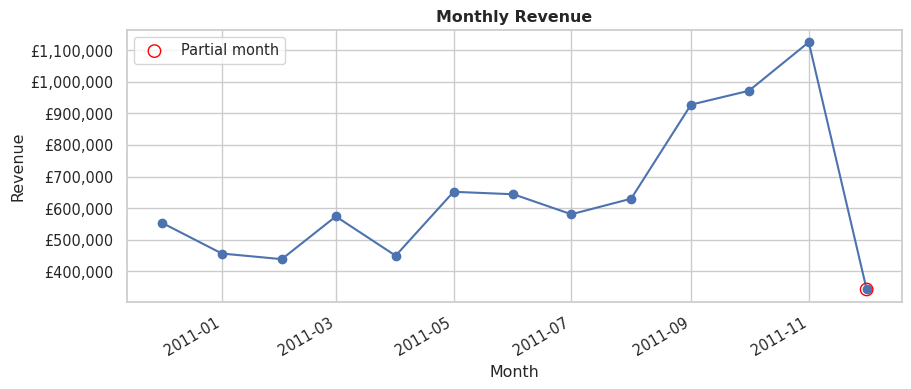

In [11]:
eda.plot_monthly_revenue(transactions);

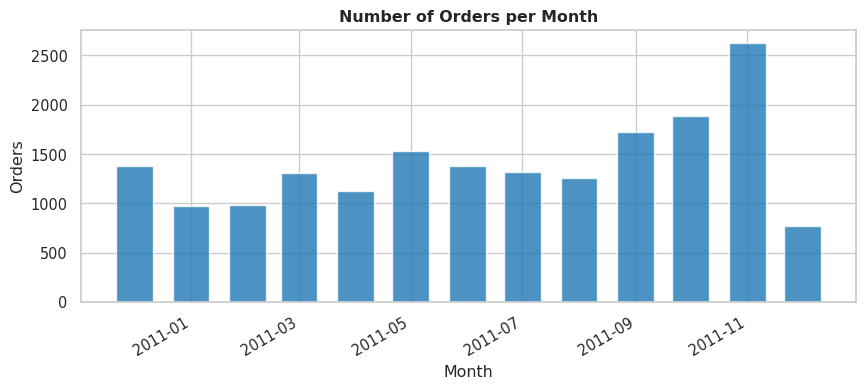

In [12]:
eda.plot_monthly_orders(transactions);

Revenue grows strongly in the autumn of 2011 and peaks in **November 2011**, which suggests seasonal demand before the holidays. December 2011 looks like a sharp drop, but the data stops on 9 December, so it is a **partial month** (marked in red) and not a real decline.

### 7.2 Products and countries

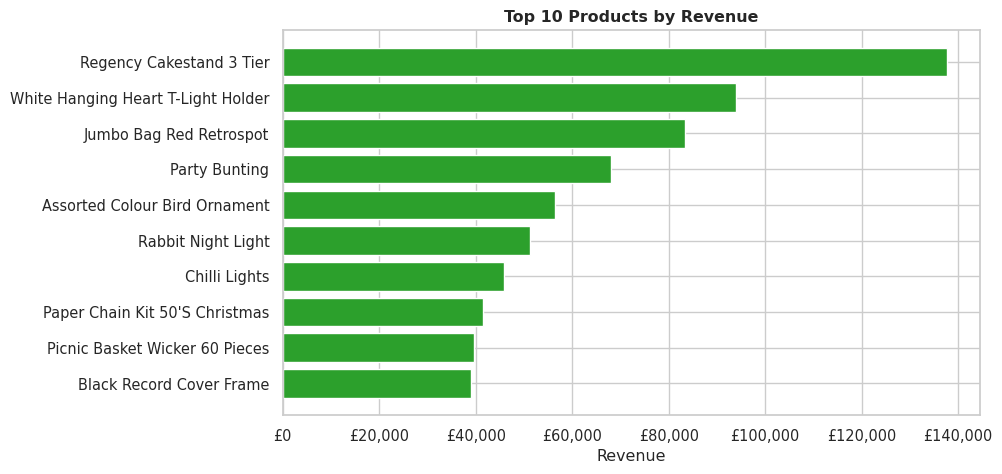

In [13]:
eda.plot_top_products(transactions);

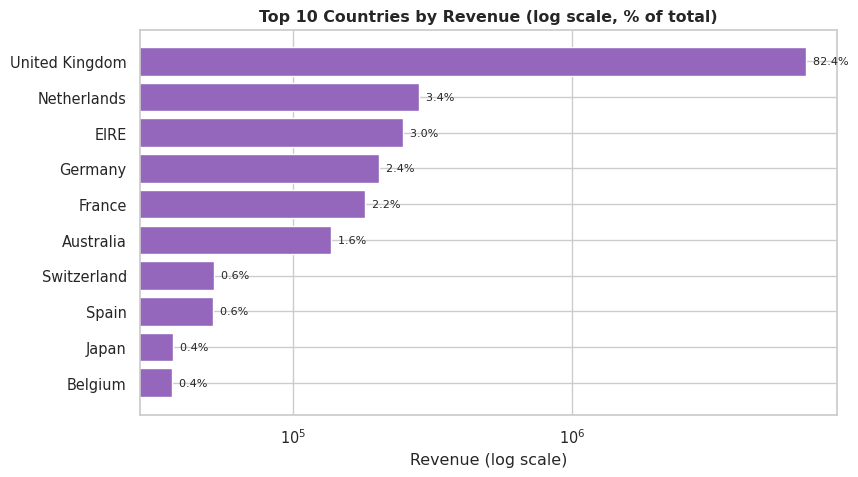

In [14]:
eda.plot_top_countries(transactions);

The United Kingdom dominates revenue (the chart uses a log scale so the other countries stay visible). Because of this imbalance, country-level comparisons outside the UK rest on relatively few customers.

### 7.3 Order values

Median order value: £300.54 | Mean order value: £456.89


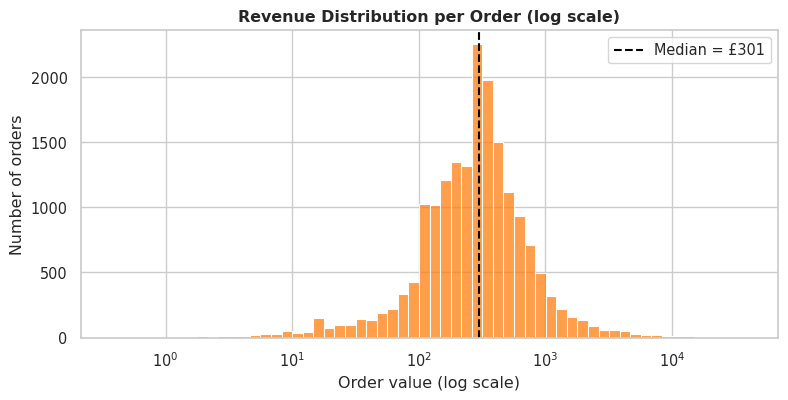

In [15]:
order_values = transactions.groupby("Invoice")["TotalAmount"].sum()
print(f"Median order value: {CURRENCY}{order_values.median():,.2f} | Mean order value: {CURRENCY}{order_values.mean():,.2f}")
eda.plot_order_value_distribution(transactions);

The mean order value is well above the median: a smaller number of large (likely wholesale) orders pulls the average up. This right skew appears again at the customer level.

## 8. Feature engineering

The cleaning step already created `TotalAmount = Quantity × UnitPrice` for every line. For each customer we now build:

- **Recency**: days between the last purchase and a *snapshot date* (one day after the last transaction in the data)
- **Frequency**: number of distinct invoices (orders), not invoice lines
- **Monetary**: total spend
- **AvgOrderValue** = Monetary / Frequency, plus the customer's main country (descriptive only, not used for clustering)

We also add classic **RFM quintile scores** (1 to 5 for each measure, 5 = best). These give a simple rule-based baseline to compare against the clusters later.

## 9. RFM calculation

In [16]:
rfm = add_rfm_scores(calculate_rfm(transactions))
snapshot = transactions["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot.date()} | Customers: {len(rfm):,}")
rfm.head()

Snapshot date: 2011-12-10 | Customers: 4,322


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Country,FirstPurchase,LastPurchase,R_Score,F_Score,M_Score,RFM_Score
0,12347,3,7,"4,310.00",615.71,Iceland,2010-12-07 14:57:00,2011-12-07 15:52:00,5,5,5,15
1,12348,76,4,"1,437.24",359.31,Finland,2010-12-16 19:09:00,2011-09-25 13:13:00,2,4,4,10
2,12349,19,1,"1,457.55","1,457.55",Italy,2011-11-21 09:51:00,2011-11-21 09:51:00,4,1,4,9
3,12350,311,1,294.40,294.40,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,1,2,4
4,12352,37,7,"1,265.41",180.77,Norway,2011-02-16 12:33:00,2011-11-03 14:37:00,3,5,4,12


## 10. RFM distributions and statistical analysis
### 10.1 Customer-level distributions

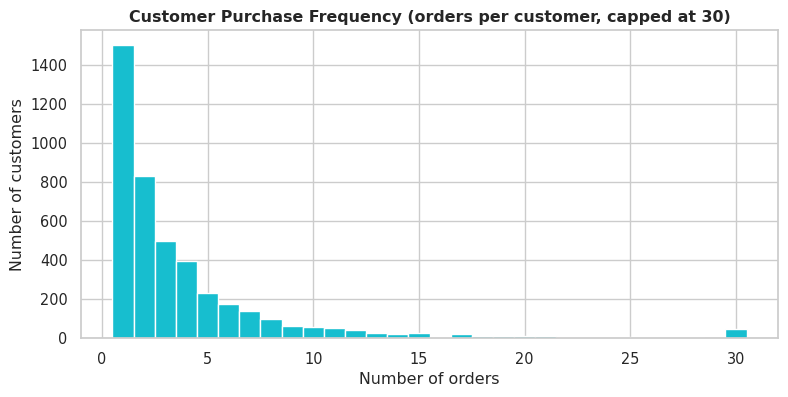

In [17]:
eda.plot_customer_frequency(rfm);

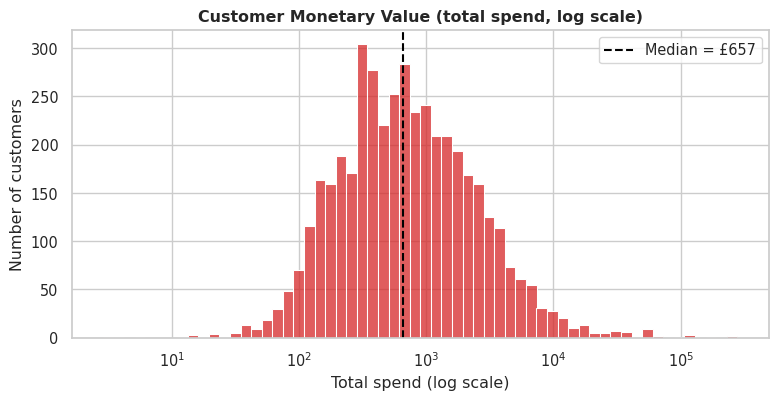

In [18]:
eda.plot_customer_monetary(rfm);

In [19]:
one_time = (rfm["Frequency"] == 1).mean() * 100
top10_share = rfm.nlargest(int(len(rfm) * 0.10), "Monetary")["Monetary"].sum() / rfm["Monetary"].sum() * 100
print(f"Customers with only one order: {one_time:.1f}%")
print(f"Revenue share of the top 10% of customers: {top10_share:.1f}%")

Customers with only one order: 34.8%
Revenue share of the top 10% of customers: 60.1%


### 10.2 Descriptive statistics

In [20]:
sa.descriptive_stats(rfm, RFM_FEATURES + ['AvgOrderValue'])

,mean,median,std,min,Q1,Q3,max,IQR,skewness,kurtosis
Recency,93.31,51.00,100.28,1.00,18.00,144.00,374.00,126.00,1.24,0.41
Frequency,4.23,2.00,7.57,1.00,1.00,5.00,204.00,4.00,11.86,241.07
Monetary,"1,930.82",656.62,"8,330.85",2.90,301.79,"1,615.32","278,778.02","1,313.52",21.38,591.10
AvgOrderValue,377.15,287.37,543.51,2.90,175.28,422.84,"19,809.75",247.56,16.49,466.38


For Frequency and Monetary, the mean is far above the median, and skewness and kurtosis are very high. A small group of customers orders far more often and spends far more than the typical customer.

In [21]:
pd.concat([sa.iqr_outlier_counts(rfm), sa.skewness_before_after_log(rfm)], axis=1)

,iqr_outliers,raw_skewness,log_skewness
Recency,140,1.24,-0.32
Frequency,273,11.86,1.22
Monetary,417,21.38,0.37


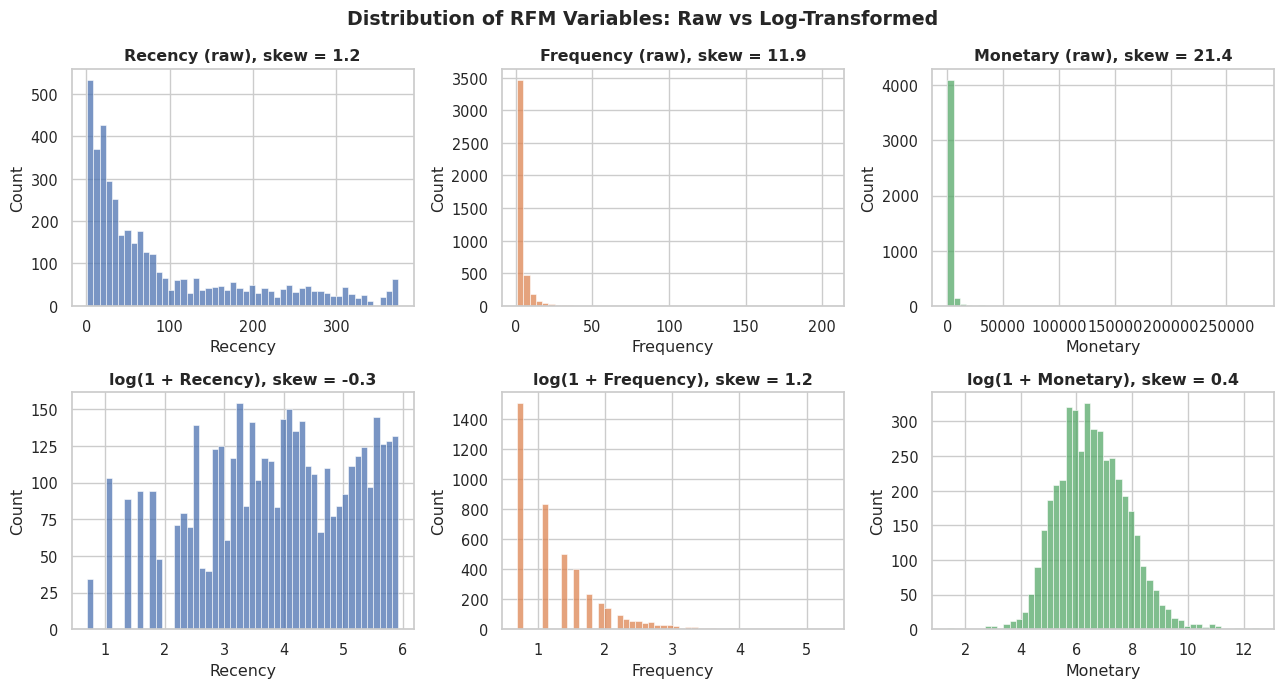

In [22]:
eda.plot_rfm_distributions(rfm);

The log transform `log(1 + x)` brings the skewness of Frequency and Monetary much closer to zero. We keep the outlying customers (they are real and important customers) but reduce their influence on distance-based clustering.

### 10.3 Correlation

In [23]:
sa.correlation_matrix(rfm)

,Recency,Frequency,Monetary
Recency,1.00,-0.57,-0.48
Frequency,-0.57,1.00,0.81
Monetary,-0.48,0.81,1.00


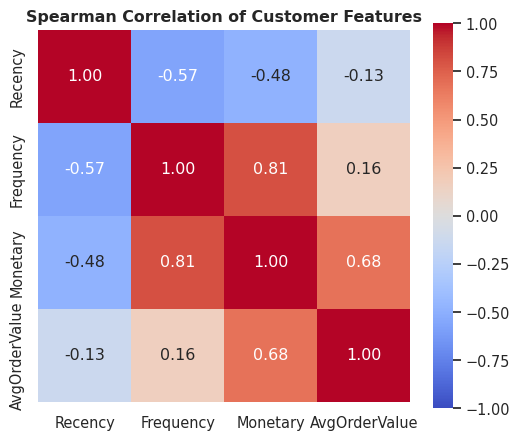

In [24]:
eda.plot_correlation_heatmap(rfm);

Spearman (rank) correlation is used because it is robust to skew. Frequency and Monetary are strongly positively related. Recency is negatively related to both: customers who bought recently also tend to buy often and spend more.

### 10.4 Hypothesis test: domestic vs international order value

- **H₀:** the distribution of average order value is the same for UK and international customers.
- **H₁:** the distributions differ (two-sided).
- **Test:** Mann-Whitney U, because order values are heavily skewed, so a t-test's normality assumption does not hold. Significance level α = 0.05.

In [25]:
test = sa.compare_domestic_vs_international(rfm)
# show the p-value in scientific notation (it is far too small for 2 decimals)
pd.Series({**test, "p_value": f"{test['p_value']:.2e}"}).to_frame("value")

,value
test,Mann-Whitney U (two-sided)
variable,AvgOrderValue
group_a,United Kingdom
group_b,International
n_group_a,3907
n_group_b,415
median_group_a,276.70
median_group_b,387.31
u_statistic,"576,353.00"
p_value,3.12e-22


If the p-value is below 0.05, we reject H₀. The rank-biserial effect size tells us how large the difference is: 0 means no difference, and a negative value means UK customers tend to have *smaller* order values. A small p-value on its own does not mean a large effect, which is why both numbers are reported.

## 11. Feature scaling

K-Means assigns points to the nearest centroid using **Euclidean distance**, so the features must be on comparable scales:

1. **Log transform** `log(1 + x)`: reduces the extreme right skew, so a few very large customers do not dominate the centroids.
2. **Standardisation** (`StandardScaler`): rescales each feature to mean 0 and standard deviation 1. Without it, Monetary (thousands) would outweigh Frequency (single digits).

In [26]:
X, scaler = clustering.prepare_features(rfm)
pd.DataFrame(X, columns=RFM_FEATURES).describe().loc[["mean", "std", "min", "max"]]

,Recency,Frequency,Monetary
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-2.42,-0.95,-4.16
max,1.58,5.86,4.78


## 12. K-Means clustering

K-Means splits the data into *k* groups by repeatedly (1) assigning each customer to the nearest centroid and (2) moving each centroid to the mean of its customers, until the assignments stop changing. It minimises the within-cluster sum of squared distances (**inertia**).

K-Means needs *k* in advance, so we evaluate k = 2 to 10 with two complementary methods.

In [27]:
k_eval = clustering.evaluate_k_range(X, k_min=2, k_max=10)
k_eval

,k,inertia,silhouette,davies_bouldin
0,2,"6,447.89",0.43,0.89
1,3,"4,821.76",0.34,1.04
2,4,"3,896.56",0.34,1.01
3,5,"3,236.94",0.32,0.98
4,6,"2,811.50",0.31,1.02
5,7,"2,505.03",0.30,0.99
6,8,"2,297.76",0.30,0.99
7,9,"2,119.23",0.28,1.02
8,10,"1,961.18",0.28,1.02


## 13. Elbow method

Inertia always decreases as *k* grows, so we look for the "elbow" where extra clusters stop giving large improvements. The elbow is detected automatically as the point farthest from the straight line joining the first and last points of the curve.

In [28]:
elbow_k = clustering.find_elbow(k_eval["k"], k_eval["inertia"])
print(f"Elbow point: k = {elbow_k}")

Elbow point: k = 5


## 14. Silhouette score

The silhouette score (from −1 to 1) measures how much closer each customer is to its own cluster than to the nearest other cluster. Higher is better.

**Selection rule (decided before looking at the results):** choose the *k* with the highest silhouette score among k ≥ 3. On RFM data, k = 2 usually scores highest because it only separates active from inactive customers, which is too coarse for segmentation.

Selected k = 3 (elbow suggested k = 5)


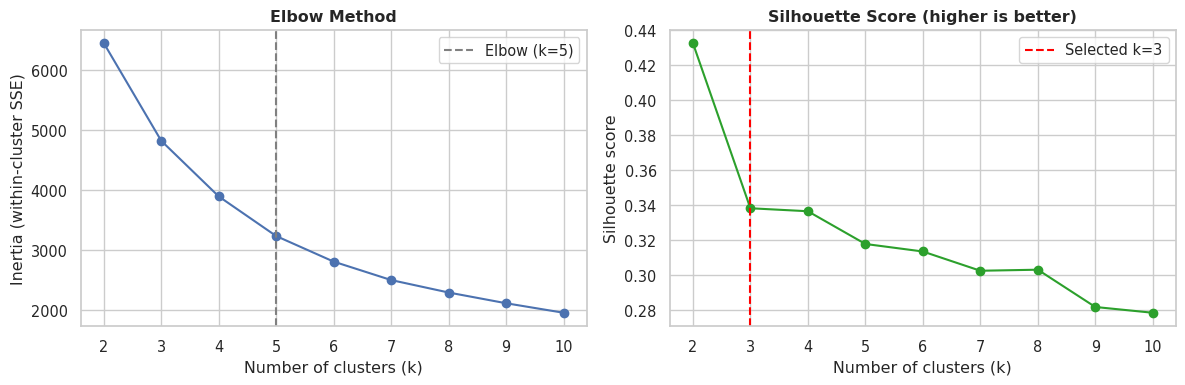

In [29]:
selected_k = clustering.select_k(k_eval, min_k=3)
print(f"Selected k = {selected_k} (elbow suggested k = {elbow_k})")
clustering.plot_k_evaluation(k_eval, selected_k, elbow_k);

The two methods do not have to agree, and here they do not: the elbow points to a larger *k* than the silhouette rule. This is common with real customer data, which forms a continuum rather than well-separated blobs. Silhouette values around 0.3 to 0.35 indicate **moderate** structure. The clusters are useful groupings, not sharply separated natural classes. Section 16.3 checks how much the conclusions depend on this choice.

In [30]:
model = clustering.train_kmeans(X, selected_k)
rfm["Cluster"] = model.labels_
stability = clustering.stability_check(X, selected_k)
print(f"Stability across 5 random seeds (mean Adjusted Rand Index): {stability:.3f}")
rfm["Cluster"].value_counts().sort_index().to_frame("customers")

Stability across 5 random seeds (mean Adjusted Rand Index): 0.977


,customers
Cluster,
0,1705
1,1860
2,757


An Adjusted Rand Index close to 1 means that different random initialisations produce almost the same clustering, so the result is reproducible.

## 15. PCA visualisation

PCA projects the three scaled features onto two new axes that keep as much variance as possible, so the clusters can be drawn in 2D.

**Important:** PCA is used here *only for visualisation*. The clustering was done in the original 3-D space, and a clear 2-D picture does not prove the clusters are "correct".

In [31]:
coords, pca = clustering.apply_pca(X)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      f"(total {pca.explained_variance_ratio_.sum():.1%})")
pd.DataFrame(pca.components_, columns=RFM_FEATURES, index=["PC1", "PC2"]).round(3)

Explained variance ratio: [0.753 0.186] (total 94.0%)


,Recency,Frequency,Monetary
PC1,-0.51,0.62,0.60
PC2,0.85,0.26,0.46


The loadings show what each axis means. PC1 combines all three RFM features and works as an overall engagement axis: frequent, high-spending, recent customers score on one side, and inactive low spenders on the other.

## 16. Cluster interpretation
### 16.1 Cluster profiles and automatic naming

Each cluster is named from its **actual** statistics. We take the cluster's mean standardised score for each feature (with the recency sign flipped so that higher is always better) and apply simple rules:

| Rule (0 = average customer, ±0.25 = "about average") | Name |
|---|---|
| recent, and frequency and spend both > 0.5 | High-Value Customers |
| recent, and frequency or spend > 0.25 | Loyal / Frequent Customers |
| recent, but frequency and spend about average or lower | Potential Customers |
| not recent, but frequency or spend > 0.25 | At-Risk Customers |
| not recent, low frequency and spend | Low-Engagement Customers |

These names are **analytical interpretations, not ground-truth labels**.

In [32]:
profile = clustering.interpret_clusters(rfm, X, model.labels_)
rfm["Segment"] = rfm["Cluster"].map(profile.set_index("Cluster")["Segment"])
profile[["Cluster", "Segment", "Customers", "CustomerSharePct", "RevenueSharePct",
         "Recency_median", "Frequency_median", "Monetary_median", "R_z", "F_z", "M_z"]]

,Cluster,Segment,Customers,CustomerSharePct,RevenueSharePct,Recency_median,Frequency_median,Monetary_median,R_z,F_z,M_z
0,0,Potential Customers,1705,39.40,24.80,30.00,3.00,939.32,0.35,0.09,0.22
1,1,Low-Engagement Customers,1860,43.00,7.90,162.00,1.00,289.87,-0.78,-0.76,-0.78
2,2,High-Value Customers,757,17.50,67.30,10.00,10.00,"3,560.32",1.12,1.65,1.41


In [33]:
for row in profile.sort_values("Revenue", ascending=False).itertuples():
    print(f"{row.Segment}\n  {row.Description}\n  Suggested action: {row.SuggestedAction}\n")

High-Value Customers
  757 customers (17.5% of customers, 67.3% of revenue). Median customer last bought 10 days ago, placed 10 order(s) and spent £3,560. Compared with the average customer: recency is more recent, frequency is higher and spending is higher.
  Suggested action: Retain with loyalty rewards, early access and personal service.

Potential Customers
  1,705 customers (39.4% of customers, 24.8% of revenue). Median customer last bought 30 days ago, placed 3 order(s) and spent £939. Compared with the average customer: recency is more recent, frequency is about average and spending is about average.
  Suggested action: Recently active with average or light buying: nurture with recommendations to grow frequency and basket size.

Low-Engagement Customers
  1,860 customers (43.0% of customers, 7.9% of revenue). Median customer last bought 162 days ago, placed 1 order(s) and spent £290. Compared with the average customer: recency is older, frequency is lower and spending is lower.


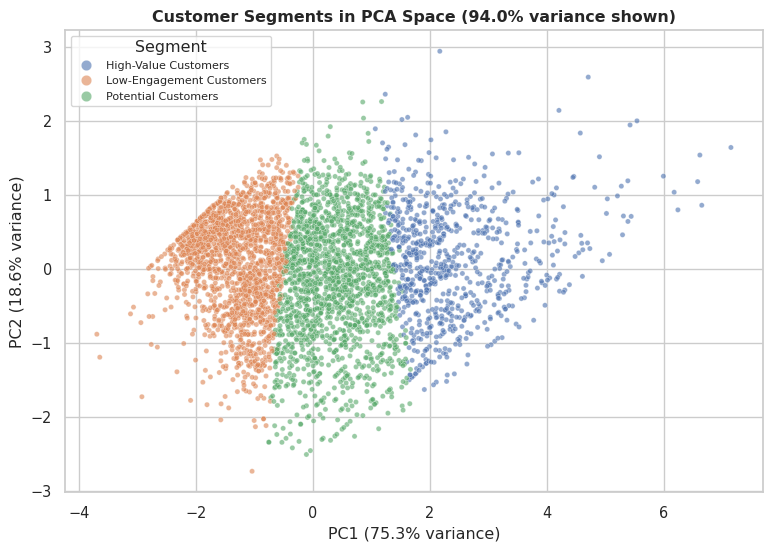

In [34]:
clustering.plot_pca_clusters(coords, rfm['Segment'], pca.explained_variance_ratio_);

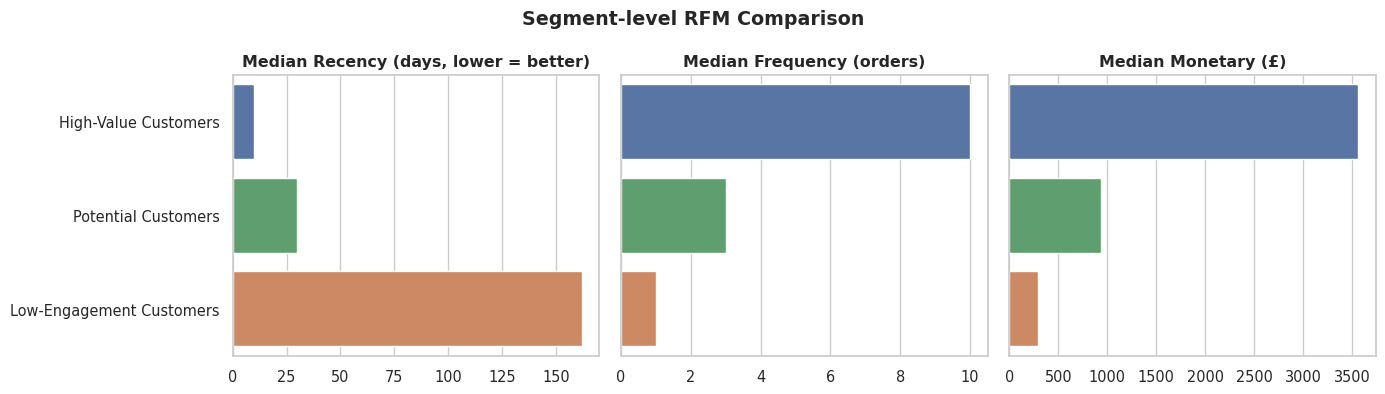

In [35]:
clustering.plot_segment_comparison(profile);

### 16.2 Sanity check against rule-based RFM scores

The quintile RFM score (3 to 15) was computed independently of K-Means. If the clusters are meaningful, the average RFM score should differ clearly between segments.

In [36]:
rfm.groupby("Segment")["RFM_Score"].agg(["mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,mean,median,min,max
Segment,,,,
High-Value Customers,14.23,14.00,11,15
Potential Customers,10.42,10.00,7,14
Low-Engagement Customers,5.56,6.00,3,9


### 16.3 Sensitivity analysis: k = 4

Silhouette scores for k = 3 and k = 4 are very close, so we check what the next option would look like.

In [37]:
model_4 = clustering.train_kmeans(X, 4)
profile_4 = clustering.interpret_clusters(rfm, X, model_4.labels_)
print("Silhouette k=4:", k_eval.loc[k_eval["k"] == 4, "silhouette"].iloc[0])
profile_4[["Segment", "Customers", "RevenueSharePct", "Recency_median", "Frequency_median", "Monetary_median"]]

Silhouette k=4: 0.3364


,Segment,Customers,RevenueSharePct,Recency_median,Frequency_median,Monetary_median
0,At-Risk Customers,1188,23.50,57.00,4.00,"1,309.37"
1,High-Value Customers,723,65.10,9.00,10.00,"3,546.71"
2,Potential Customers,863,5.30,19.00,2.00,429.84
3,Low-Engagement Customers,1548,6.20,185.00,1.00,288.51


With k = 4 the high-value group stays almost the same, but the middle of the customer base is reorganised. A separate **At-Risk** group appears: customers with a solid order history who have not bought for a while. The **Potential** group becomes smaller and holds recent customers with only one or two orders. Both solutions are defensible. We keep the pre-declared rule (k = 3) as the main result and treat k = 4 as a finer alternative. The pipeline supports it with `python run_pipeline.py --k 4`.

## 17. Business insights

In [38]:
seg = profile.set_index("Segment")
hv = seg.loc["High-Value Customers"] if "High-Value Customers" in seg.index else None
print(f"Top 10% of customers generate {top10_share:.1f}% of revenue.")
print(f"{one_time:.1f}% of customers ordered only once.")
if hv is not None:
    print(f"High-Value segment: {hv['CustomerSharePct']:.1f}% of customers -> {hv['RevenueSharePct']:.1f}% of revenue.")
print(f"UK median avg order value {CURRENCY}{test['median_group_a']:,.2f} vs international {CURRENCY}{test['median_group_b']:,.2f} "
      f"(p = {test['p_value']:.2g}).")

Top 10% of customers generate 60.1% of revenue.
34.8% of customers ordered only once.
High-Value segment: 17.5% of customers -> 67.3% of revenue.
UK median avg order value £276.70 vs international £387.31 (p = 3.1e-22).


Based on the full-dataset results:

1. **Revenue is concentrated.** A small high-value group generates most of the revenue. Keeping these customers (loyalty benefits, priority service) matters more than any other single action.
2. **Many customers never return.** About a third of customers ordered only once. Improving the step from the first to the second purchase is the main growth opportunity for the *Potential* group.
3. **The low-engagement group is large but low value.** Automated, low-cost re-engagement fits better than expensive campaigns.
4. **Seasonality.** Revenue peaks in the autumn months, so retention and win-back campaigns are best timed before the peak season.
5. **International customers** place larger orders on average than UK customers (statistically significant, with a small-to-moderate effect). They may include more wholesale buyers, which is worth investigating before designing country-specific offers.

These insights are based on one retailer's historical data. They are hypotheses to test (for example with A/B tests), not guaranteed outcomes.

## 18. Conclusion

- We cleaned 541,909 raw transaction lines with documented, reproducible decisions. The most important one was matching cancellations to the purchases they cancel.
- RFM features were heavily right-skewed. A log transform followed by standardisation made them suitable for K-Means.
- The elbow method and silhouette analysis were used together to choose *k*. They disagreed, which we reported openly, and a sensitivity check showed how the segments change with k = 4.
- The clusters are reproducible (high stability ARI) and agree with independent rule-based RFM scores.
- Segment names were derived automatically from cluster statistics and turned into practical actions.

**Limitations:** one retailer, about one year of data, mostly UK customers. RFM ignores *what* customers buy. K-Means assumes roughly spherical clusters. Customers without an ID were excluded.

**Future scope:** add product-category features, try other algorithms (Gaussian Mixture Models, DBSCAN), track how customers move between segments over time, and predict customer lifetime value.